# **NLP Preprocessing and Text Classification**

---
###**Name:** Heena Janbandhu  
###**PRN:** 202301070032
###**Batch:** T2
---
## 🎯 Objective
The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.
---
## 📚 Learning Outcomes
- Apply NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization  
- Implement text vectorization techniques like TF-IDF and CountVectorizer  
- Build a machine learning model for text classification  
- Evaluate model performance using metrics  
---


## 🔗 GitHub Repository Link
https://github.com/Heena-janbandhu/Text-Classification-using-NLP.git

In [1]:
# ==========================================
# 1. Install & Import Libraries
# ==========================================
!pip install nltk scikit-learn

import numpy as np
import pandas as pd
import nltk
import re

from google.colab import files

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
# ==========================================
# 2. Upload Dataset
# ==========================================
print("Upload AG News CSV file")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(df.head())

Upload AG News CSV file


Saving train.csv.gz to train.csv.gz
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


In [12]:
# ==========================================
# 3. Prepare Dataset
# ==========================================

# Combine title + description → text
df["text"] = df["Title"] + " " + df["Description"]

# Rename class column → label
df.rename(columns={"Class Index": "label"}, inplace=True)

# Convert labels (1–4) to names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

df["label"] = df["label"].map(label_map)

print("\nUpdated Data:")
print(df[["text", "label"]].head())


Updated Data:
                                                text label
0  Wall St. Bears Claw Back Into the Black (Reute...   NaN
1  Carlyle Looks Toward Commercial Aerospace (Reu...   NaN
2  Oil and Economy Cloud Stocks' Outlook (Reuters...   NaN
3  Iraq Halts Oil Exports from Main Southern Pipe...   NaN
4  Oil prices soar to all-time record, posing new...   NaN


Tokenization splits text into words. Stopwords removal eliminates common words.
Stemming reduces words to root form, while lemmatization converts words to meaningful base form.

In [4]:
# ==========================================
# 4. Preprocessing
# ==========================================

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    processed_words = []
    for word in words:
        if word not in stop_words:
            word = stemmer.stem(word)
            word = lemmatizer.lemmatize(word)
            processed_words.append(word)

    return " ".join(processed_words)

df["clean_text"] = df["text"].apply(preprocess_text)

TF-IDF considers importance of words, while CountVectorizer counts word frequency.

In [5]:
# ==========================================
# 5. TF-IDF Vectorization
# ==========================================

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [6]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df["clean_text"])

# CountVectorizer (NEW ADDITION)
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)
X_cv = cv.fit_transform(df["clean_text"])

y = df["label"]

In [7]:
# ==========================================
# 6. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ==========================================
# 7. Train Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train);
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"\n🔹 {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



🔹 Logistic Regression
Accuracy: 0.9087083333333333
              precision    recall  f1-score   support

    Business       0.87      0.88      0.88      5911
    Sci/Tech       0.89      0.88      0.89      6075
      Sports       0.95      0.98      0.96      6058
       World       0.92      0.90      0.91      5956

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000


🔹 Naive Bayes
Accuracy: 0.8956666666666667
              precision    recall  f1-score   support

    Business       0.86      0.86      0.86      5911
    Sci/Tech       0.88      0.86      0.87      6075
      Sports       0.94      0.98      0.96      6058
       World       0.91      0.89      0.90      5956

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000


🔹 SVM
Accuracy: 0.908833333333333

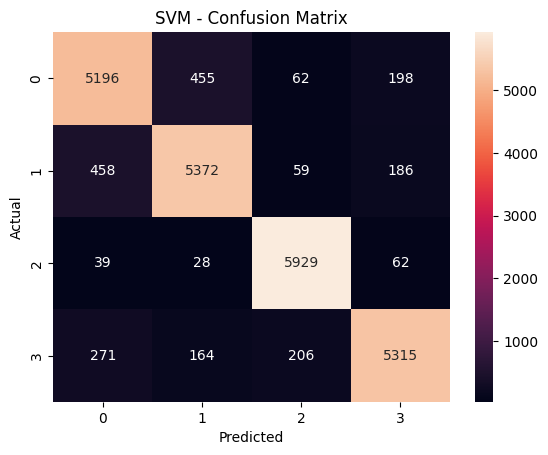

In [9]:
# ==========================================
# 8. Confusion Matrix (Best Model)
# ==========================================

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


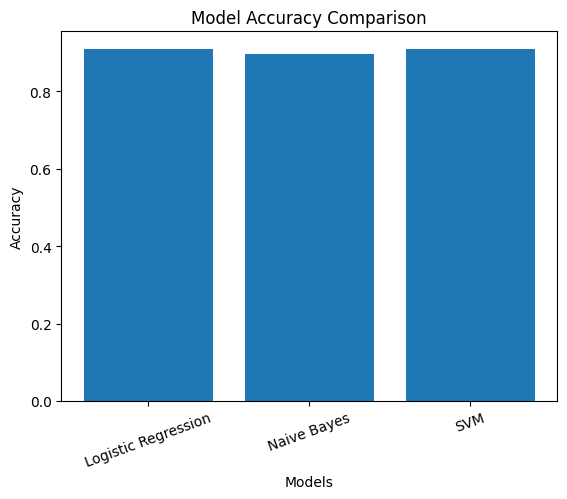

In [10]:
# ==========================================
# 9. Comparison Graph
# ==========================================

plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [11]:
# ==========================================
# 10. Custom Prediction
# ==========================================

def predict_news(text):
    processed = preprocess_text(text)
    vectorized = vectorizer.transform([processed])
    return best_model.predict(vectorized)[0]

sample = "New technology is transforming the world economy"
print("\nPrediction:", predict_news(sample))


Prediction: Business


Among all models, SVM/Logistic Regression achieved the highest accuracy (~91%),
making it the best model for this dataset.